# Notebook 4 - Deep Learning (DL)

In [1]:
stable = False
!pip install {"tsai -U" if stable else "git+https://github.com/timeseriesAI/tsai.git"} >> /dev/null

  Running command git clone --filter=blob:none --quiet https://github.com/timeseriesAI/tsai.git /tmp/pip-req-build-_uf6yeiq
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cpu requires torch==2.10.0, but you have torch 2.12.0 which is incompatible.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tsai.all import *
from contextlib import redirect_stdout
import io
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# 1. Učitavanje podataka

In [3]:
df = pd.read_csv('/kaggle/input/datasets/mrossini03/cleaned-data/cleaned_data.csv')
df.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,air_temperature,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,25.0,20.0,0.0,1019.7,0.0,0.0
1,1,0,2016-01-01 00:00:00,0.0,0,Education,2720,25.0,20.0,0.0,1019.7,0.0,0.0
2,2,0,2016-01-01 00:00:00,0.0,0,Education,5376,25.0,20.0,0.0,1019.7,0.0,0.0
3,3,0,2016-01-01 00:00:00,0.0,0,Education,23685,25.0,20.0,0.0,1019.7,0.0,0.0
4,4,0,2016-01-01 00:00:00,0.0,0,Education,116607,25.0,20.0,0.0,1019.7,0.0,0.0


# 2. Izbacivanje metrika koje nisu električna energija

Na početku bilježnice napravit ću isti postupak kao i na početku treće. Dakle, napravit ću skup podataka koji sadrži samo stupce timestamp i Total_Consumption.

In [4]:
df = df[df['meter'] == 0]

# 3. Stvaranje agregiranog skupa podataka

In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df_agg = df.groupby('timestamp')['meter_reading'].sum().reset_index()
df_agg.columns = ['timestamp', 'Total_Consumption']
df_agg.head()

,timestamp,Total_Consumption
0,2016-01-01 00:00:00,108210.6934
1,2016-01-01 01:00:00,123960.7990
2,2016-01-01 02:00:00,124223.9960
3,2016-01-01 03:00:00,124206.2139
4,2016-01-01 04:00:00,124680.8483


# 4. Kreiranje window funkcije

U ovom dijelu ću napraviti funkciju create_windows koja će za svaki uzorak pridružiti ws prethodnih uzoraka. To znači da ostajemo bez prvih ws uzoraka. 

In [6]:
def create_windows(series, ws):
    X, y = [], []
    for i in range(len(series) - ws):
        X.append(series[i:i + ws])
        y.append(series[i + ws])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# 5. Podjela podataka na skup za učenje i testiranje

Radimo jednaku podjelu podataka kao u prošloj bilježnici, skup za učenje i skup za testiranje u omjeru 70/30.

In [7]:
n = len(df_agg)
split = int(n * 0.70)

df_agg = df_agg.set_index('timestamp')
train = df_agg['Total_Consumption'].iloc[:split]
test = df_agg['Total_Consumption'].iloc[split:]

print(f"Train size: {len(train)} | Test size: {len(test)}")

Train size: 12280 | Test size: 5264


# 6. Skaliranje podataka

Budući da radimo s dubokim modelima, skaliranje podataka je potrebno. Koristit ću MinMax skaliranje koje će sve podatke iz skupa za učenje skalirati između 0 i 1. Moguće je da podaci iz skupa za testiranje budu izvan tog intervala, ali će podaci ipak biti skalirani.

In [8]:
scaler = MinMaxScaler()

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
test_scaled  = scaler.transform(test.values.reshape(-1, 1)).flatten()

In [9]:
ws = 24

X_train, y_train = create_windows(train_scaled, ws)
X_test, y_test  = create_windows(test_scaled, ws)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (12256, 24)
X_test shape: (5240, 24)


Windowing utječe na skup podataka na način da ulazne podatke (što je vektor duljine n) pretvori u skup podataka dimenzija (n-ws, ws). Dakle, svaki podatak sad sadrži informaciju o prethodnih ws podataka. Gubimo informaciju o prvih ws uzoraka jer za njih nemamo dovoljno podataka.

In [10]:
X_train_ts = X_train[:, np.newaxis, :]
X_test_ts = X_test[:, np.newaxis, :]

print(f"X_train shape: {X_train_ts.shape}")
print(f"X_test shape: {X_test_ts.shape}")

X_train shape: (12256, 1, 24)
X_test shape: (5240, 1, 24)


# 7. InceptionTime

Potrebno je odabrati jedan od od modela HydraMultiRocketPlus i InceptionTime. Ja sam se odlučio za InceptionTime model, koji je trenutačno najtočnija arhitektura dubokih neuronskih
mreža za klasifikaciju općenitih vremenskih nizova.

## 7.1. Osnovni model

Na početku ću isprobati model s hiperparametrima ws = 24, batch_size = 32 i epochs = 10.

epoch,train_loss,time
0,0.002043,00:30
1,0.001508,00:29
2,0.001192,00:30
3,0.000868,00:30
4,0.000725,00:30
5,0.000768,00:30
6,0.000516,00:30
7,0.000412,00:29
8,0.000366,00:29
9,0.000289,00:29


Baseline InceptionTime — RMSE: 5580.95 | MAE: 2228.54


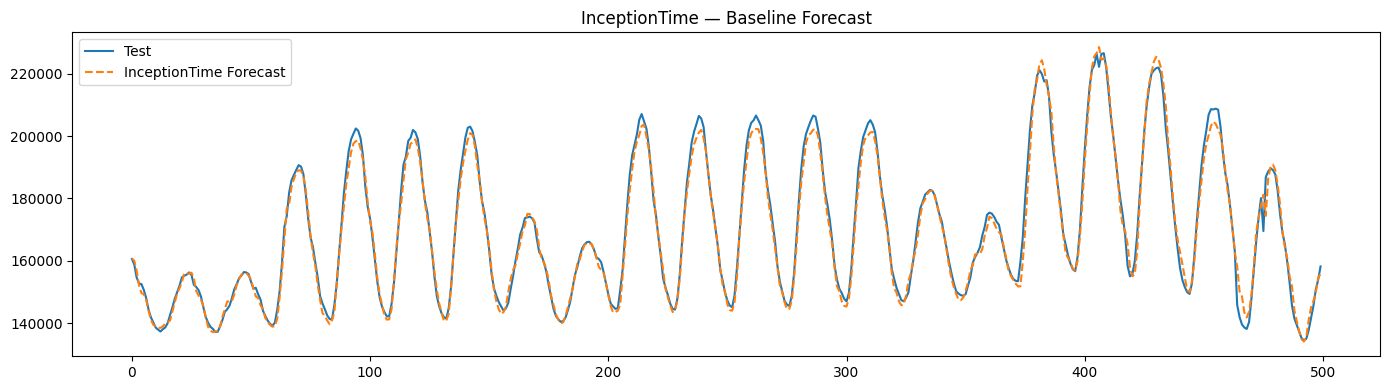

In [11]:
tfms  = [None, []]
dsets = TSDatasets(X_train_ts, y_train, tfms=tfms)
dls   = TSDataLoaders.from_dsets(
    dsets.train, dsets.valid,
    bs=32,
    num_workers=0
)

model_base = InceptionTime(1, 1)
learn_base = ts_learner(dls, model_base, loss_func=MSELossFlat())
with redirect_stdout(io.StringIO()):
    learn_base.fit_one_cycle(10)


pred_base_scaled, *_ = learn_base.get_X_preds(X_test_ts)
pred_base_scaled = pred_base_scaled.numpy().flatten()

pred_base = scaler.inverse_transform(pred_base_scaled.reshape(-1, 1)).flatten()
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

rmse_base = np.sqrt(mean_squared_error(y_test_orig, pred_base))
mae_base  = mean_absolute_error(y_test_orig, pred_base)
print(f"Baseline InceptionTime — RMSE: {rmse_base:.2f} | MAE: {mae_base:.2f}")

plt.figure(figsize=(14, 4))
plt.plot(range(500), y_test_orig[:500], label='Test')
plt.plot(range(500), pred_base[:500], linestyle='--', label='InceptionTime Forecast')
plt.title('InceptionTime — Baseline Forecast')
plt.legend()
plt.tight_layout()
plt.show()

it_results = [{
    'ws': ws, 'epochs': 10, 'batch_size': 32,
    'RMSE': round(rmse_base, 2), 'MAE': round(mae_base, 2)
}]

## 7.2. Optimiranje hiperparametara

Ovdje ću isprobati nekoliko različitih kombinacija hiperparametara. Zbog računalne složenosti neću provoditi grid search jer bi to predugo trajalo.

In [12]:
configs = [
    {'ws': 24, 'epochs': 10, 'bs': 64},
    {'ws': 48, 'epochs': 10, 'bs': 32},
    {'ws': 168, 'epochs': 10, 'bs': 64},
]

best_rmse_it = rmse_base
best_mae_it = mae_base
best_pred_it = pred_base
best_y_it = y_test_orig
best_cfg_it = {'ws': 24, 'epochs': 10, 'bs': 32}

for cfg in configs:
    print(f"\nTreniram: {cfg}")

    X_tr, y_tr = create_windows(train_scaled, cfg['ws'])
    X_te, y_te = create_windows(test_scaled,  cfg['ws'])
    X_tr = X_tr[:, np.newaxis, :]
    X_te = X_te[:, np.newaxis, :]

    dsets = TSDatasets(X_tr, y_tr, tfms=tfms)
    dls   = TSDataLoaders.from_dsets(
        dsets.train, dsets.valid,
        bs=cfg['bs'], num_workers=0
    )

    model = InceptionTime(1, 1)
    learn = ts_learner(dls, model, loss_func=MSELossFlat())
    learn.fit_one_cycle(cfg['epochs'])

    pred_scaled, *_ = learn.get_X_preds(X_te)
    pred_scaled = pred_scaled.numpy().flatten()
    pred = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    y_orig = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_orig, pred))
    mae  = mean_absolute_error(y_orig, pred)
    print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f}")

    it_results.append({
        'ws': cfg['ws'], 'epochs': cfg['epochs'], 'batch_size': cfg['bs'],
        'RMSE': round(rmse, 2), 'MAE': round(mae, 2)
    })

    if rmse < best_rmse_it:
        best_rmse_it = rmse
        best_mae_it = mae
        best_pred_it = pred
        best_y_it = y_orig
        best_cfg_it = cfg


Treniram: {'ws': 24, 'epochs': 10, 'bs': 64}


epoch,train_loss,time
0,0.002241,00:24
1,0.001434,00:24
2,0.001415,00:24
3,0.001044,00:24
4,0.000830,00:23
5,0.000607,00:24
6,0.000537,00:23
7,0.000437,00:23
8,0.000250,00:23
9,0.000321,00:23


RMSE: 5633.42 | MAE: 2146.32

Treniram: {'ws': 48, 'epochs': 10, 'bs': 32}


epoch,train_loss,time
0,0.002301,00:45
1,0.001966,00:45
2,0.001625,00:45
3,0.001388,00:45
4,0.000751,00:44
5,0.000720,00:45
6,0.000594,00:45
7,0.000547,00:45
8,0.000280,00:45
9,0.000261,00:45


RMSE: 5651.59 | MAE: 2281.09

Treniram: {'ws': 168, 'epochs': 10, 'bs': 64}


epoch,train_loss,time
0,0.007177,02:01
1,0.001423,01:59
2,0.001118,01:59
3,0.000992,01:58
4,0.000798,01:59
5,0.000661,01:59
6,0.000608,01:59
7,0.000463,01:58
8,0.000355,02:01
9,0.000352,02:00


RMSE: 8169.77 | MAE: 3685.45


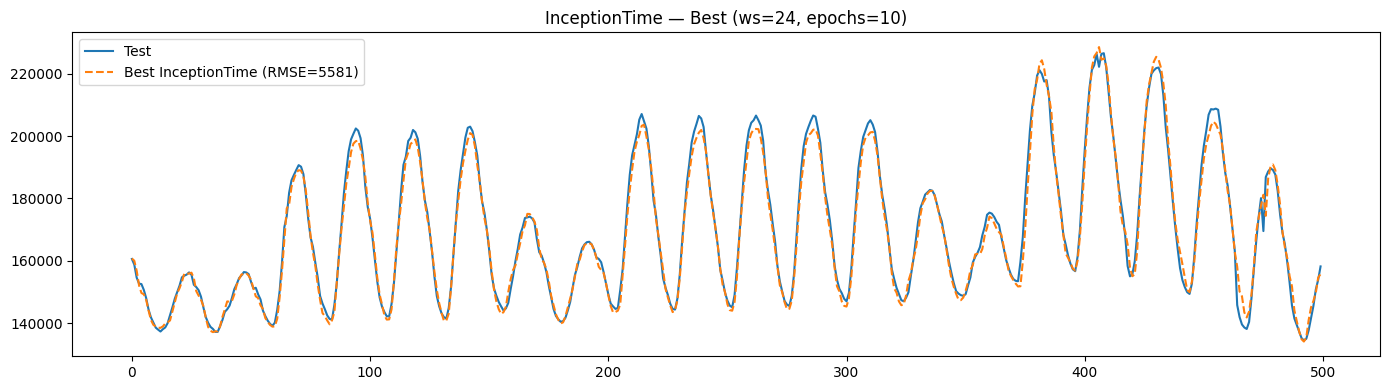

 ws  epochs  batch_size    RMSE     MAE
 24      10          32 5580.95 2228.54
 24      10          64 5633.42 2146.32
 48      10          32 5651.59 2281.09
168      10          64 8169.77 3685.45


In [13]:
plt.figure(figsize=(14, 4))
plt.plot(range(500), best_y_it[:500], label='Test')
plt.plot(range(500), best_pred_it[:500], linestyle='--',
         label=f'Best InceptionTime (RMSE={best_rmse_it:.0f})')
plt.title(f"InceptionTime — Best (ws={best_cfg_it['ws']}, epochs={best_cfg_it['epochs']})")
plt.legend()
plt.tight_layout()
plt.show()

summary = pd.DataFrame(it_results).sort_values('RMSE').reset_index(drop=True)
print(summary.to_string(index=False))

Djeluje da modeli s manjim ws ostvaruju bolje rezultate. Ostvareno je blago poboljšanje u odnosu na model RandomForesta iz Notebook 3. Ispada da je prvi isprobani model ostvario skoro pa najbolji rezultat, ali općenito modeli s manjim prozorom daju bolje rezultate.

# 8. LSTM

LSTM je primjer rekurentne neuronske mreže koji je dobar za učenje dugotrajnih ovisnosti na većim skupovima podataka. Sastavljen je od tri glavna dijela, koji su input gate, forget gate i output gate. Input gate odlučuje koliki dio informacije propušta na temelju ulaza i prošlog skrivenog stanja ćelije, dok forget gate odlučuje koliki dio informacija prošlog stanja treba zaboraviti jer više nije relevantno. Output gate na kraju odlučuje o izlazu modela.

## 8.1. Definicija modela

In [14]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

## 8.2. Funkcija za treniranje LSTM modela

Ovdje se nalazi kod potreban za treniranje LSTM modela.

In [15]:
def train_lstm(ws=24, hidden_size=64, num_layers=1, lr=0.001,
               batch_size=32, max_epochs=30, patience=3, dropout=0.0):

    X_tr, y_tr = create_windows(train_scaled, ws)
    X_te, y_te = create_windows(test_scaled,  ws)

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).unsqueeze(-1)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    X_te_t = torch.tensor(X_te, dtype=torch.float32).unsqueeze(-1)
    y_te_t = torch.tensor(y_te, dtype=torch.float32)

    val_split = int(len(X_tr_t) * 0.90)
    X_val_t, y_val_t = X_tr_t[val_split:], y_tr_t[val_split:]
    X_tr_t, y_tr_t = X_tr_t[:val_split], y_tr_t[:val_split]

    train_loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=batch_size, shuffle=False
    )

    model = LSTMModel(hidden_size=hidden_size, num_layers=num_layers, dropout=dropout)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss = np.inf
    patience_counter = 0
    best_weights = None

    for epoch in range(max_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_weights)

    model.eval()
    with torch.no_grad():
        pred_scaled = model(X_te_t).numpy()

    pred = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    y_orig = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_orig, pred))
    mae  = mean_absolute_error(y_orig, pred)
    return pred, y_orig, rmse, mae

## 8.3. Osnovni model

Prvo će biti isproban LSTM model s hiperparametrima ws=24, hidden_size=64, num_layers=1, lr=0.001, batch_size=32, max_epochs=30 i patience=5.

Treniram baseline LSTM...
  Early stopping at epoch 29
Baseline LSTM — RMSE: 6395.26 | MAE: 2611.54


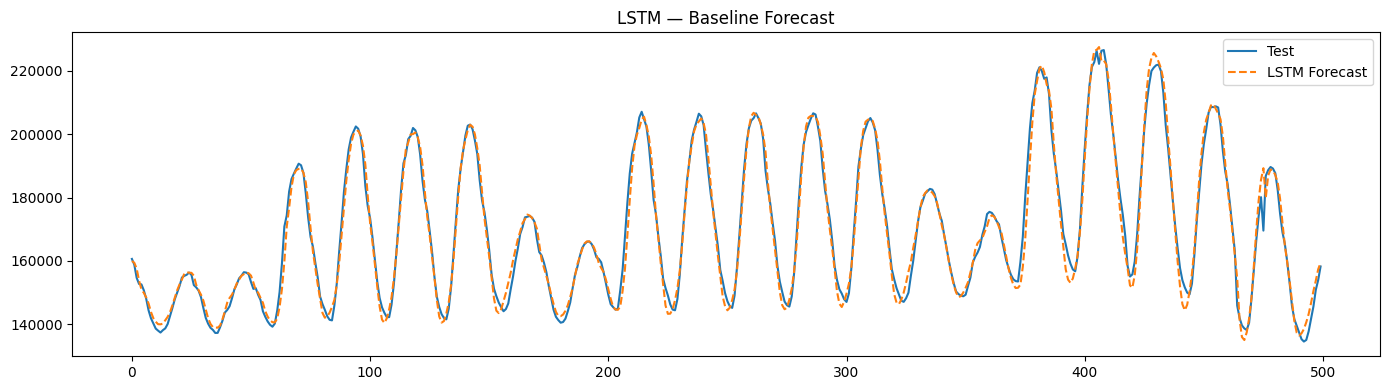

In [16]:
print("Treniram baseline LSTM...")
pred_base, y_orig, rmse_base, mae_base = train_lstm(
    ws=24, hidden_size=64, num_layers=1,
    lr=0.001, batch_size=32, max_epochs=30, patience=5
)
print(f"Baseline LSTM — RMSE: {rmse_base:.2f} | MAE: {mae_base:.2f}")

plt.figure(figsize=(14, 4))
plt.plot(range(500), y_orig[:500], label='Test')
plt.plot(range(500), pred_base[:500], linestyle='--', label='LSTM Forecast')
plt.title('LSTM — Baseline Forecast')
plt.legend()
plt.tight_layout()
plt.show()

lstm_results = [{
    'ws': 24, 'hidden_size': 64, 'num_layers': 1, 'lr': 0.001, 'max_epochs': 30,
    'batch_size': 32, 'patience': 5, 'dropout': 0.0, 'RMSE': round(rmse_base, 2), 'MAE': round(mae_base, 2)
}]

## 8.4. Optimiranje hiperparametara

Sad ću isprobati nekoliko različitih kombinacija hiperparametara. Opet, zbog računalne složenosti neću provoditi grid search već samo nekoliko različitih kombinacija.

In [17]:
configs = [
    {'ws': 24, 'hidden_size': 128, 'num_layers': 1, 'lr': 0.001, 'max_epochs': 30, 'batch_size': 32, 'patience': 3, 'dropout': 0.0},
    {'ws': 48, 'hidden_size': 64, 'num_layers': 1, 'lr': 0.001, 'max_epochs': 30, 'batch_size': 32, 'patience': 3, 'dropout': 0.0},
    {'ws': 168, 'hidden_size': 64, 'num_layers': 1, 'lr': 0.001, 'max_epochs': 30, 'batch_size': 64, 'patience': 3, 'dropout': 0.0},
    {'ws': 48, 'hidden_size': 128, 'num_layers': 2, 'lr': 0.001, 'max_epochs': 50, 'batch_size': 32, 'patience': 5, 'dropout': 0.2},
    {'ws': 24, 'hidden_size': 64, 'num_layers': 2, 'lr': 0.001, 'max_epochs': 50, 'batch_size': 32, 'patience': 7, 'dropout': 0.1},
    {'ws': 48, 'hidden_size': 64, 'num_layers': 2, 'lr': 0.001, 'max_epochs': 50, 'batch_size': 32, 'patience': 7, 'dropout': 0.1},
]

best_rmse_lstm = rmse_base
best_mae_lstm = mae_base
best_pred_lstm = pred_base
best_y_lstm = y_test
best_cfg_lstm = {'ws': 24, 'hidden_size': 64, 'num_layers': 1, 'lr': 0.001, 'max_epochs': 30, 'batch_size': 32, 'patience': 5, 'dropout': 0.0}

for cfg in configs:
    print(f"\nTreniram: ws={cfg['ws']} hidden_size={cfg['hidden_size']} num_layers={cfg['num_layers']} lr={cfg['lr']} max_epochs={cfg['max_epochs']} batch_size={cfg['batch_size']} patience={cfg['patience']} dropout={cfg['dropout']}")
    pred, y_orig, rmse, mae = train_lstm(**cfg)
    print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f}")

    lstm_results.append({
        'ws': cfg['ws'], 'hidden_size': cfg['hidden_size'], 'num_layers': cfg['num_layers'],
        'lr': cfg['lr'], 'max_epochs': cfg['max_epochs'], 'batch_size': cfg['batch_size'], 'patience': cfg['patience'],
        'dropout': cfg['dropout'], 'RMSE': round(rmse, 2), 'MAE': round(mae, 2)
    })

    if rmse < best_rmse_lstm:
        best_rmse_lstm, best_mae_lstm, best_pred_lstm, best_y_lstm, best_cfg_lstm = rmse, mae, pred, y_orig, cfg


Treniram: ws=24 hidden_size=128 num_layers=1 lr=0.001 max_epochs=30 batch_size=32 patience=3 dropout=0.0
  Early stopping at epoch 20
RMSE: 6486.85 | MAE: 2641.58

Treniram: ws=48 hidden_size=64 num_layers=1 lr=0.001 max_epochs=30 batch_size=32 patience=3 dropout=0.0
RMSE: 6214.09 | MAE: 2801.23

Treniram: ws=168 hidden_size=64 num_layers=1 lr=0.001 max_epochs=30 batch_size=64 patience=3 dropout=0.0
RMSE: 6216.54 | MAE: 2706.93

Treniram: ws=48 hidden_size=128 num_layers=2 lr=0.001 max_epochs=50 batch_size=32 patience=5 dropout=0.2
  Early stopping at epoch 27
RMSE: 5950.89 | MAE: 2688.77

Treniram: ws=24 hidden_size=64 num_layers=2 lr=0.001 max_epochs=50 batch_size=32 patience=7 dropout=0.1
RMSE: 5399.19 | MAE: 2239.77

Treniram: ws=48 hidden_size=64 num_layers=2 lr=0.001 max_epochs=50 batch_size=32 patience=7 dropout=0.1
  Early stopping at epoch 36
RMSE: 5955.11 | MAE: 2593.77


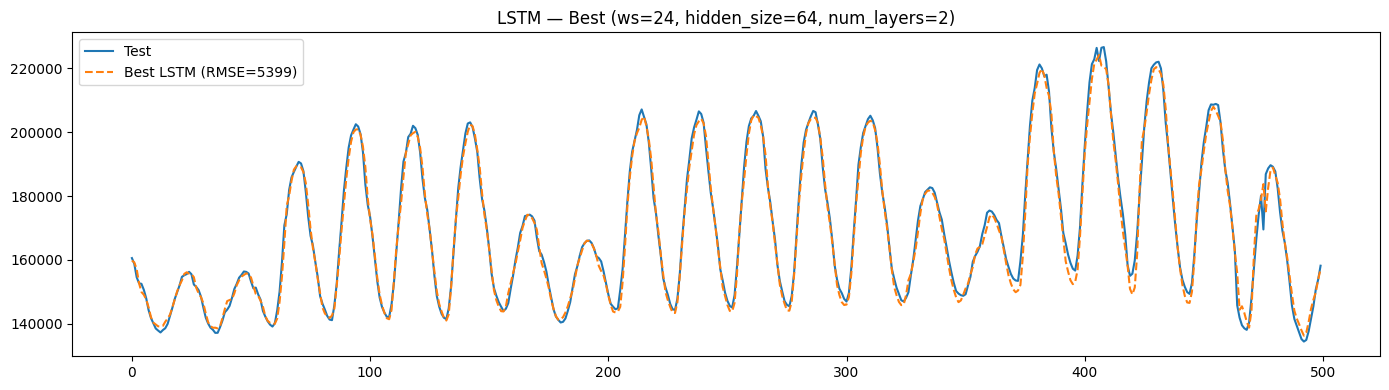

 ws  hidden_size  num_layers    lr  max_epochs  batch_size  patience  dropout    RMSE     MAE
 24           64           2 0.001          50          32         7      0.1 5399.19 2239.77
 48          128           2 0.001          50          32         5      0.2 5950.89 2688.77
 48           64           2 0.001          50          32         7      0.1 5955.11 2593.77
 48           64           1 0.001          30          32         3      0.0 6214.09 2801.23
168           64           1 0.001          30          64         3      0.0 6216.54 2706.93
 24           64           1 0.001          30          32         5      0.0 6395.26 2611.54
 24          128           1 0.001          30          32         3      0.0 6486.85 2641.58


In [18]:
plt.figure(figsize=(14, 4))
plt.plot(range(500), best_y_lstm[:500], label='Test')
plt.plot(range(500), best_pred_lstm[:500], linestyle='--',
         label=f'Best LSTM (RMSE={best_rmse_lstm:.0f})')
plt.title(f"LSTM — Best (ws={best_cfg_lstm['ws']}, hidden_size={best_cfg_lstm['hidden_size']}, num_layers={best_cfg_lstm['num_layers']})")
plt.legend()
plt.tight_layout()
plt.show()

summary = pd.DataFrame(lstm_results).sort_values('RMSE').reset_index(drop=True)
print(summary.to_string(index=False))

Najbolji LSTM modeli su, kao i ranije InceptionTime, uspjeli ostvariti blago poboljšanje u odnosu na rezultate RandomForest modela iz prošle bilježnice. Optimiranjem hiperparametra ostvareno je poboljšanje u odnosu na prvi isprobani model. 

# 9. Dodatne vizualizacije

In [19]:
df_reset = df_agg.reset_index()

test_timestamps = df_reset['timestamp'].iloc[split + ws:split + ws + len(best_y_lstm)].values

results_df = pd.DataFrame({
    'timestamp': pd.to_datetime(test_timestamps),
    'actual':    best_y_lstm,
    'LSTM':      best_pred_lstm,
})
results_df['hour']        = results_df['timestamp'].dt.hour
results_df['day_of_week'] = results_df['timestamp'].dt.dayofweek
results_df['abs_err']     = np.abs(results_df['actual'] - results_df['LSTM'])
results_df['residual']    = results_df['actual'] - results_df['LSTM']

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

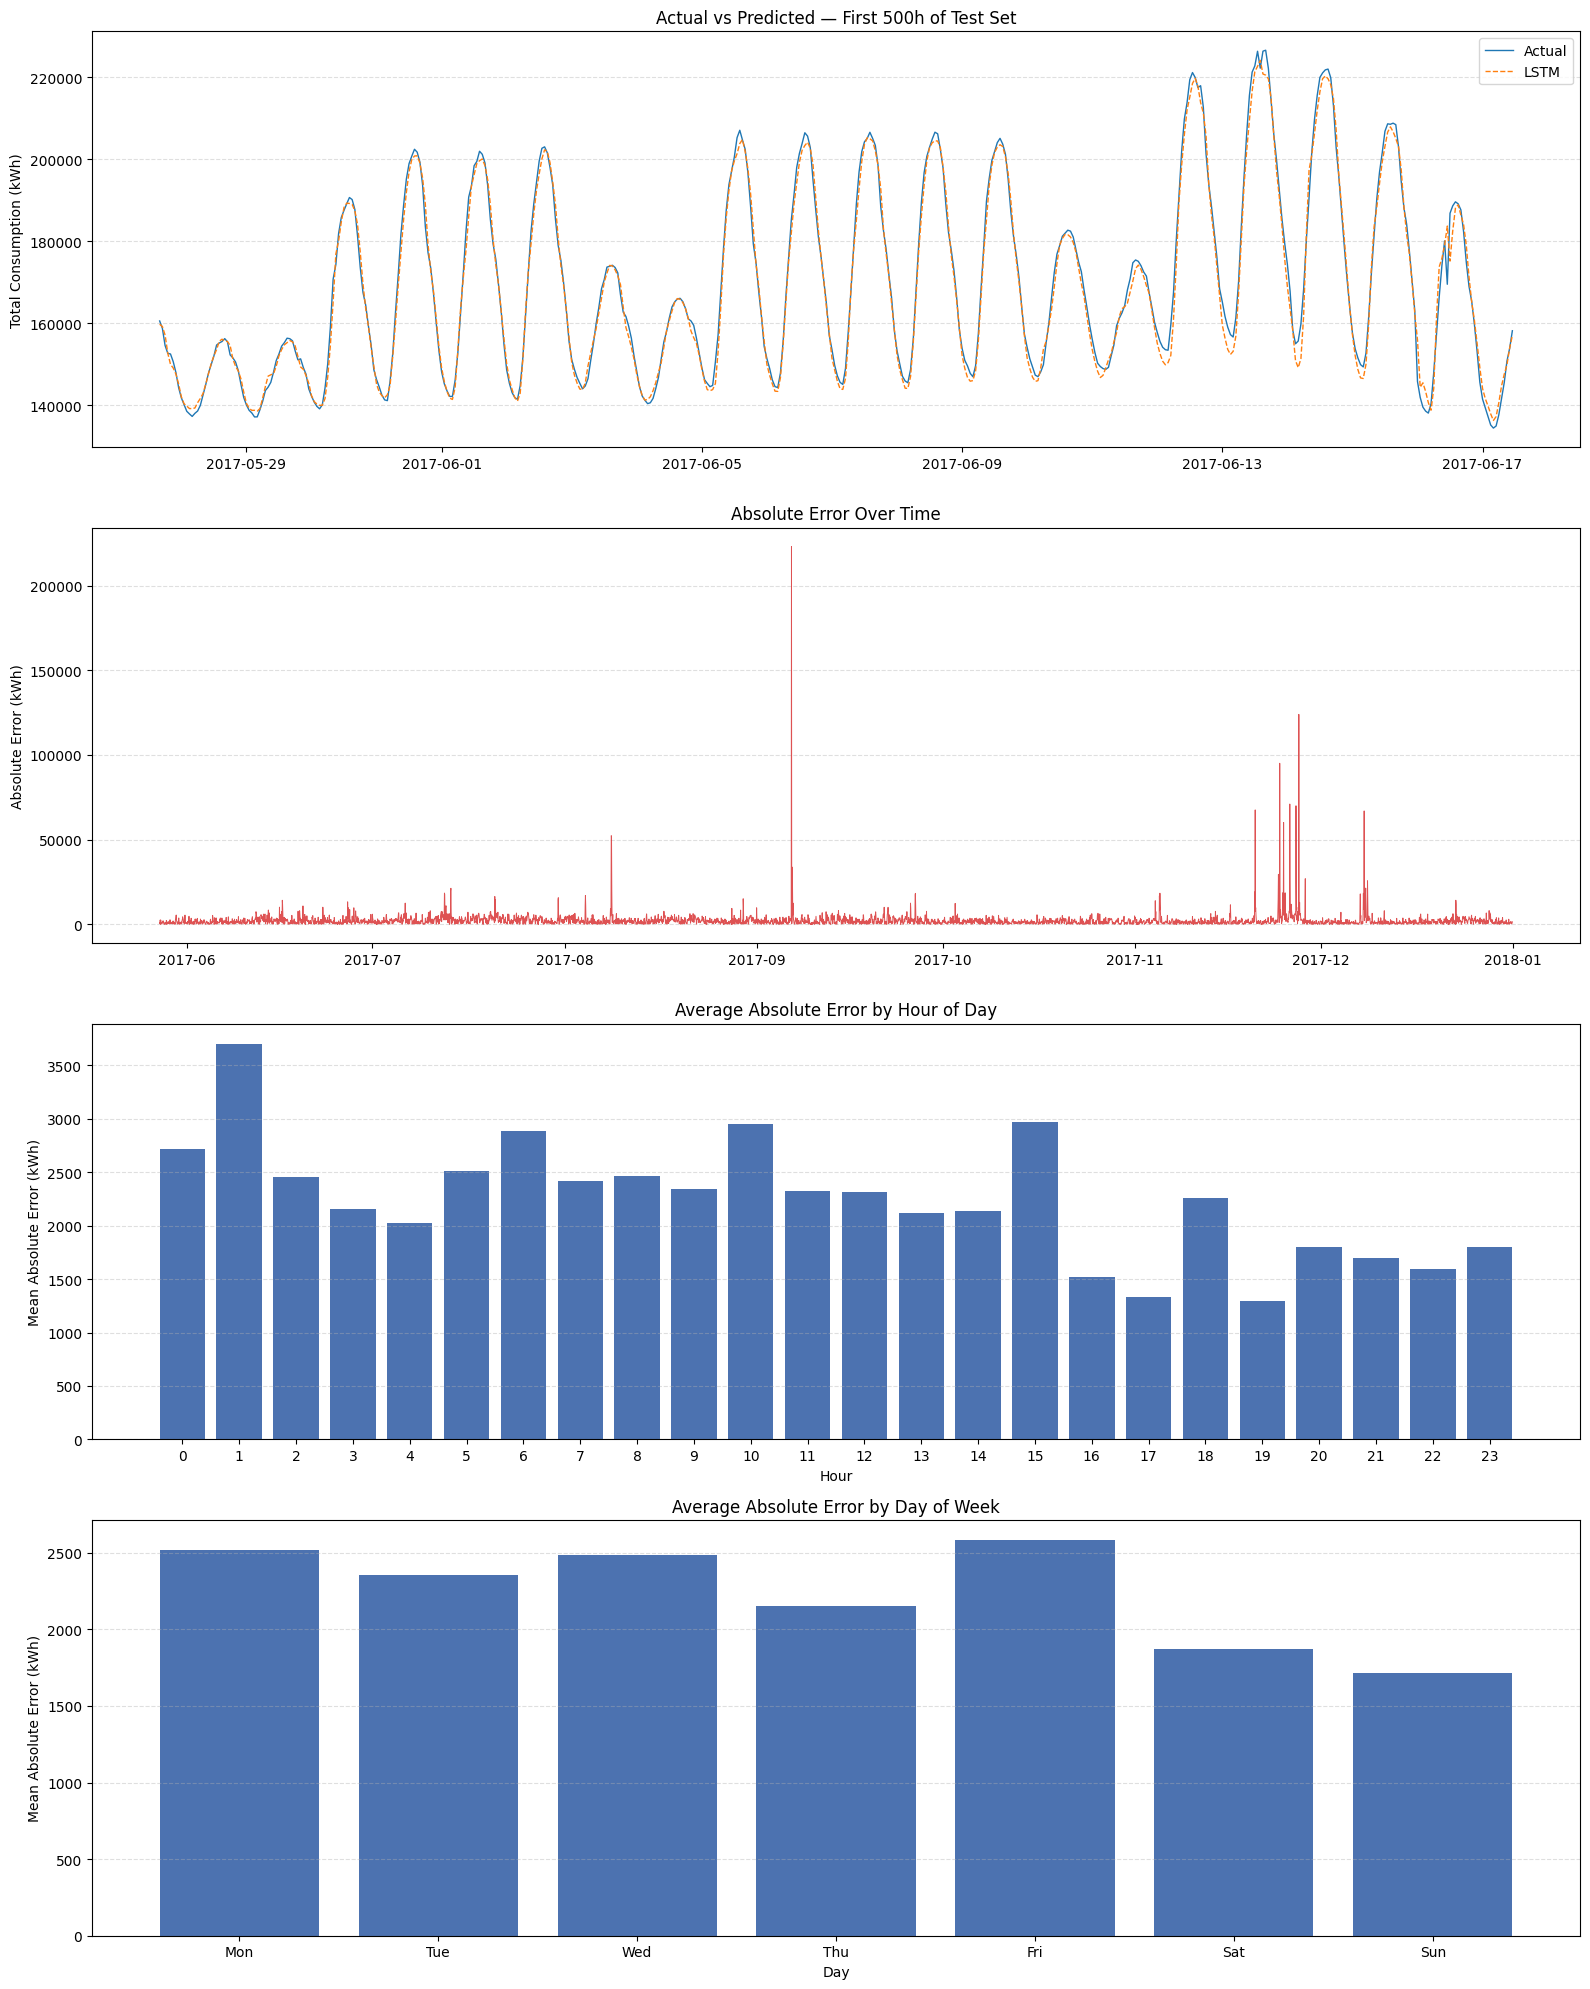

In [20]:
fig, axes = plt.subplots(4, 1, figsize=(16, 20))

ax = axes[0]
ax.plot(results_df['timestamp'].iloc[:500], results_df['actual'].iloc[:500],
        label='Actual', linewidth=1)
ax.plot(results_df['timestamp'].iloc[:500], results_df['LSTM'].iloc[:500],
        linestyle='--', linewidth=1, label='LSTM')
ax.set_title('Actual vs Predicted — First 500h of Test Set')
ax.set_ylabel('Total Consumption (kWh)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax = axes[1]
ax.plot(results_df['timestamp'], results_df['abs_err'],
        linewidth=0.7, alpha=0.8, color='#d62728')
ax.set_title('Absolute Error Over Time')
ax.set_ylabel('Absolute Error (kWh)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax = axes[2]
err_by_hour = results_df.groupby('hour')['abs_err'].mean()
ax.bar(range(24), err_by_hour.values, color='#4C72B0')
ax.set_title('Average Absolute Error by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Mean Absolute Error (kWh)')
ax.set_xticks(range(24))
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax = axes[3]
err_by_day = results_df.groupby('day_of_week')['abs_err'].mean()
ax.bar(range(7), err_by_day.values, color='#4C72B0')
ax.set_title('Average Absolute Error by Day of Week')
ax.set_xlabel('Day')
ax.set_ylabel('Mean Absolute Error (kWh)')
ax.set_xticks(range(7))
ax.set_xticklabels(days)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Apsolutna greška u LSTM modelu više manje je potpuno stabilna, uz nekoliko spikeova. Jedini dio gdje djeluje da postoje neki problemi je oko 12. mjeseca 2017. Što se tiče greške po satima, ona je nešto veća u 1 ujutro, što ima smisla zbog toga što je tada može doći do neke nepredvidljive potrošnje. S druge strane, za dane u tjednu najveća greška je obično ponedjeljkom, što isto ima smila jer je početak tjedna pa je teže uloviti neke trendove, dok je neočekivano velika pogreška i četvrtkom.

# 10. Završna usporedba

In [21]:
final_comparison = pd.DataFrame([
    {
        'Model': 'InceptionTime',
        'Key Parameters': f'ws={best_cfg_it["ws"]}, epochs={best_cfg_it["epochs"]}, bs={best_cfg_it["bs"]}',
        'RMSE': round(best_rmse_it, 2),
        'MAE':  round(best_mae_it, 2)
    },
    {
        'Model': 'LSTM',
        'Key Parameters': f'ws={best_cfg_lstm["ws"]}, hidden={best_cfg_lstm["hidden_size"]}, layers={best_cfg_lstm["num_layers"]}, lr={best_cfg_lstm["lr"]}',
        'RMSE': round(best_rmse_lstm, 2),
        'MAE':  round(best_mae_lstm, 2)
    },
])

final_comparison = final_comparison.sort_values('RMSE').reset_index(drop=True)
print(final_comparison.to_string(index=False))

        Model                       Key Parameters    RMSE     MAE
         LSTM ws=24, hidden=64, layers=2, lr=0.001 5399.19 2239.77
InceptionTime              ws=24, epochs=10, bs=32 5580.95 2228.54


Oba modela ostvarili su blaga napredovanja u odnosu na rezultate iz treće bilježnice. Lakši model za treniranje bio je LSTM koji je bio vremenski brži. 

Duboki modeli su dobri za bolje hvatanje nelinearnih i vremensko-ovisnih obrazaca i za učenje značajki iz sirovih podataka smanjuje se potreba za ručnim feature engineeringom.

S druge strane, duboki modeli obično zahtijevaju velike količine podataka uz rizik overfittinga na malim skupovima i većih su računalnih troškova te dužeg vremena treniranja. Isto tako, rezultati su češće teži za interpretirati zbog kompleksnosti modela.